Dataset Head:
    area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000

Dataset Description:
               area          price
count     5.000000       5.000000
mean   3280.000000  626000.000000
std     540.370243   74949.983322
min    2600.000000  550000.000000
25%    3000.000000  565000.000000
50%    3200.000000  610000.000000
75%    3600.000000  680000.000000
max    4000.000000  725000.000000


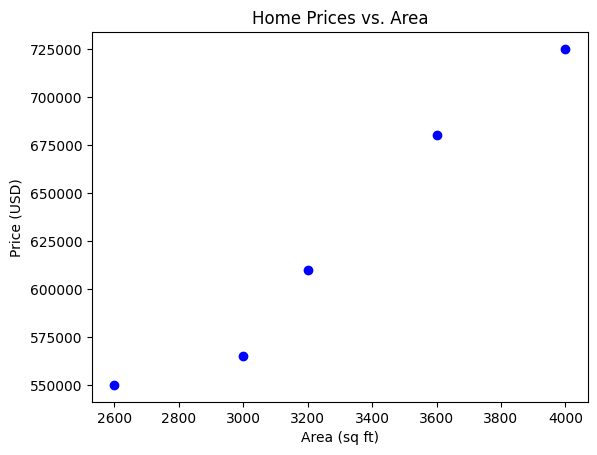

In [ ]:
##1. Data Loading and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('homeprices.csv')

# Explore the dataset
print("Dataset Head:\n", df.head())
print("\nDataset Description:\n", df.describe())

# Visualize the data
plt.scatter(df['area'], df['price'], color='blue', marker='o')
plt.title('Home Prices vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (USD)')
plt.show()

In [ ]:
##2. Data Preparation and Splitting
from sklearn.model_selection import train_test_split

# Define feature (X) and target (y)
X = df[['area']] # Feature must be a 2D DataFrame/array
y = df['price']  # Target is a 1D Series

# Split the data (80% training, 20% testing)
# Note: With only 5 rows, this yields 4 training rows and 1 testing row.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4, 1)
Testing data shape: (1, 1)


In [ ]:
##3. Building the Model
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# View the mathematical components
print(f"Coefficient (m): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")

Coefficient (m): 128.27102803738316
Intercept (b): 211542.05607476638


In [ ]:
##4. Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) # Note: R2 cannot be properly calculated with only 1 test sample.

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2) Score: {r2}")

Mean Absolute Error (MAE): 31355.140186915873
Mean Squared Error (MSE): 983144816.1411468
Root Mean Squared Error (RMSE): 31355.140186915873
R-squared (R2) Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


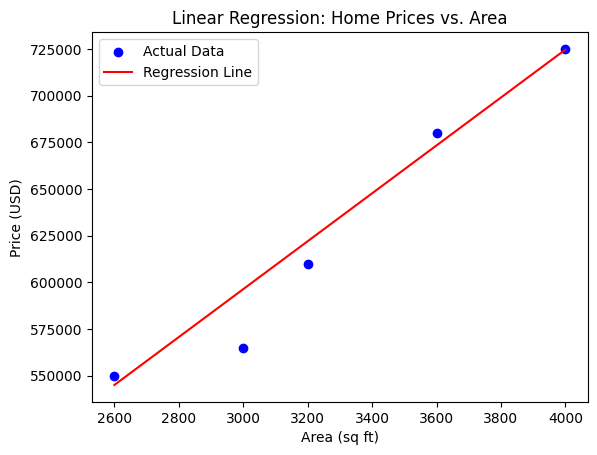

In [ ]:
##5. Visualizing the Results
# Predict across the whole dataset to draw the regression line
y_pred_all = model.predict(X)

plt.scatter(X, y, color='blue', marker='o', label='Actual Data')
plt.plot(X, y_pred_all, color='red', label='Regression Line')
plt.title('Linear Regression: Home Prices vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()